In [ ]:
# ============================================================
# CELL 1: Mount Google Drive and install required libraries
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Install libraries not pre-installed in Colab
!pip install lightgbm optuna shap torch-geometric -q

print("Libraries installed successfully.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.9 MB/s eta 0:00:00
Libraries installed successfully.


In [ ]:
# ============================================================
# CELL 2a: Find the exact path to your zip file
# ============================================================

import os

# Search for the zip file in your Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Group group 2 2.zip
/content/drive/MyDrive/22424230_assignment6.zip
/content/drive/MyDrive/22424230_a1_code_submission.zip
/content/drive/MyDrive/CLASS RECORDINGS/DEPLOYMENT.zip
/content/drive/MyDrive/assignment2/train.zip
/content/drive/MyDrive/assignment2/test.zip
/content/drive/MyDrive/THESIS/archive (1).zip


In [ ]:
# ============================================================
# Extract dataset and load all SSA price records
# ============================================================

import zipfile
import os
import pandas as pd
import numpy as np

# ---- Correct path to your dataset in Google Drive ----
ZIP_PATH = '/content/drive/MyDrive/THESIS/archive (1).zip'
EXTRACT_PATH = '/content/wfp_data/'

# ---- Extract zip ----
print("Extracting dataset...")
os.makedirs(EXTRACT_PATH, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("Extraction complete. Files found:")
print(os.listdir(EXTRACT_PATH))

# ---- SSA country codes ----
SSA_CODES = set([
    'AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD','COM',
    'COD','COG','CIV','DJI','GNQ','ERI','ETH','GAB','GMB','GHA',
    'GIN','GNB','KEN','LSO','LBR','MDG','MWI','MLI','MRT','MUS',
    'MOZ','NAM','NER','NGA','RWA','STP','SEN','SLE','SOM','ZAF',
    'SSD','SDN','SWZ','TZA','TGO','UGA','ZMB','ZWE'
])

# ---- Load all yearly files ----
print("\nLoading SSA records...")
all_dfs = []
for year in range(2015, 2026):
    fpath = f'{EXTRACT_PATH}wfp_food_prices_global_{year}.csv'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        ssa = df[df['countryiso3'].isin(SSA_CODES)].copy()
        ssa['year'] = year
        all_dfs.append(ssa)
        print(f"  {year}: {len(ssa):,} SSA rows loaded")

combined = pd.concat(all_dfs, ignore_index=True)
combined['date'] = pd.to_datetime(combined['date'])

print(f"\nTotal SSA records: {len(combined):,}")
print(f"Countries: {combined['countryiso3'].nunique()}")
print(f"Markets:   {combined['market'].nunique()}")
print(f"Date range: {combined['date'].min().date()} to {combined['date'].max().date()}")
print("\nCell 2 complete.")

Extracting dataset...
Extraction complete. Files found:
['wfp_food_prices_global_2018.csv', 'wfp_food_prices_global_2024.csv', 'wfp_food_prices_global_2020.csv', 'wfp_food_prices_global_2022.csv', 'wfp_food_prices_global_2021.csv', 'wfp_food_prices_global_2017.csv', 'wfp_food_prices_global_2026.csv', 'wfp_food_prices_global_2019.csv', 'wfp_food_prices_global_2016.csv', 'wfp_food_prices_global_2023.csv', 'wfp_food_prices_global_2015.csv', 'wfp_food_prices_global_2025.csv']

Loading SSA records...
  2015: 78,688 SSA rows loaded
  2016: 63,931 SSA rows loaded
  2017: 76,351 SSA rows loaded
  2018: 84,613 SSA rows loaded
  2019: 101,016 SSA rows loaded
  2020: 173,895 SSA rows loaded
  2021: 204,883 SSA rows loaded
  2022: 196,139 SSA rows loaded
  2023: 202,749 SSA rows loaded
  2024: 208,081 SSA rows loaded
  2025: 211,131 SSA rows loaded

Total SSA records: 1,601,477
Countries: 42
Markets:   3006
Date range: 2015-01-15 to 2025-12-15

Cell 2 complete.


In [ ]:
# ============================================================
# CELL 3: Filter staples, clean prices, subregion labels
# ============================================================

# ---- Staple commodities ----
STAPLES = ['Maize (white)', 'Maize', 'Sorghum', 'Millet',
           'Rice (imported)', 'Rice (local)', 'Cassava flour', 'Wheat flour']

# ---- Harmonise maize variants into one label ----
combined['commodity'] = combined['commodity'].replace({'Maize (white)': 'Maize'})
STAPLES = ['Maize', 'Sorghum', 'Millet', 'Rice (imported)',
           'Rice (local)', 'Cassava flour', 'Wheat flour']

# ---- Filter to staples only ----
df = combined[combined['commodity'].isin(STAPLES)].copy()
print(f"Staple records: {len(df):,}")
print(f"Commodity breakdown:\n{df['commodity'].value_counts()}")

# ---- Remove extreme outliers (winsorise at 99.5th percentile) ----
upper = df['usdprice'].quantile(0.995)
df = df[df['usdprice'] <= upper].copy()
df = df[df['usdprice'] > 0].copy()
print(f"\nAfter winsorisation: {len(df):,} records")
print(f"USD price range: {df['usdprice'].min():.4f} to {df['usdprice'].max():.2f}")

# ---- Log-transform price (target variable) ----
df['log_price'] = np.log(df['usdprice'])

# ---- Subregion labels ----
WEST    = ['NGA','GHA','SEN','MLI','NER','BFA','CIV','GMB','GIN','LBR',
           'SLE','TGO','BEN','MRT','CAF','GNB','CPV','STP']
EAST    = ['ETH','KEN','TZA','UGA','RWA','BDI','SOM','SSD','DJI','ERI','SDN']
SOUTH   = ['ZAF','MOZ','ZMB','ZWE','MWI','BWA','LSO','NAM','SWZ','MDG','COM','MUS']
CENTRAL = ['COD','COG','CMR','GAB','CAF','TCD']

def get_subregion(iso):
    if iso in WEST:    return 'West'
    if iso in EAST:    return 'East'
    if iso in SOUTH:   return 'Southern'
    if iso in CENTRAL: return 'Central'
    return 'Other'

df['subregion'] = df['countryiso3'].map(get_subregion)
print(f"\nSubregion breakdown:\n{df['subregion'].value_counts()}")

# ---- Price type and flag encoding ----
df['pricetype_enc'] = (df['pricetype'] == 'Wholesale').astype(int)
df['priceflag_enc'] = (df['priceflag'] == 'aggregate').astype(int)

# ---- Month and year features ----
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year

# ---- Shock indicator flags ----
df['covid_flag']   = (df['date'] >= '2020-03-01').astype(int)
df['ukraine_flag'] = (df['date'] >= '2022-03-01').astype(int)

# ---- Commodity encoding ----
from sklearn.preprocessing import LabelEncoder
le_commodity  = LabelEncoder()
le_subregion  = LabelEncoder()
df['commodity_enc'] = le_commodity.fit_transform(df['commodity'])
df['subregion_enc'] = le_subregion.fit_transform(df['subregion'])

print("\nCell 3 complete.")
print(f"Columns so far: {list(df.columns)}")

Staple records: 302,114
Commodity breakdown:
commodity
Maize              86096
Rice (imported)    53401
Millet             47515
Rice (local)       44351
Sorghum            34502
Wheat flour        20118
Cassava flour      16131
Name: count, dtype: int64

After winsorisation: 299,823 records
USD price range: 0.0006 to 98.68

Subregion breakdown:
subregion
West        166856
East         65043
Southern     34811
Central      33037
Other           76
Name: count, dtype: int64

Cell 3 complete.
Columns so far: ['countryiso3', 'date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'year', 'log_price', 'subregion', 'pricetype_enc', 'priceflag_enc', 'month', 'covid_flag', 'ukraine_flag', 'commodity_enc', 'subregion_enc']


In [ ]:
# ============================================================
# Lagged features, rolling volatility, spatial lag
# ============================================================

# ---- Sort for correct lag computation ----
df = df.sort_values(['countryiso3', 'market', 'commodity', 'date']).reset_index(drop=True)

# ---- Group key for market-commodity series ----
group_key = ['countryiso3', 'market', 'commodity']

# ---- Lagged log price features ----
print("Computing lagged price features...")
for lag in [1, 2, 3, 6]:
    df[f'lag_{lag}'] = df.groupby(group_key)['log_price'].shift(lag)

# ---- Rolling 6-month log price standard deviation ----
df['rolling_vol'] = (
    df.groupby(group_key)['log_price']
    .transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).std())
)

print(f"Lag features created. Missing lag_1: {df['lag_1'].isna().sum():,}")
print(f"Missing lag_6: {df['lag_6'].isna().sum():,}")
print(f"Missing rolling_vol: {df['rolling_vol'].isna().sum():,}")

# ---- Spatial lag (inverse-distance weighted neighbour price at t-1) ----
print("\nComputing spatial lag feature...")

# Get unique market locations
market_coords = (
    df[['market', 'countryiso3', 'latitude', 'longitude']]
    .dropna(subset=['latitude', 'longitude'])
    .drop_duplicates(subset=['market', 'countryiso3'])
    .reset_index(drop=True)
)

from scipy.spatial import cKDTree

coords_rad = np.radians(market_coords[['latitude', 'longitude']].values)
tree = cKDTree(coords_rad)

# For each market find 5 nearest neighbours (excluding itself)
EARTH_RADIUS_KM = 6371.0
k_neighbours = 6  # 5 neighbours + itself

distances, indices = tree.query(coords_rad, k=k_neighbours)

# Build neighbour lookup: market_id -> list of (neighbour_market, weight)
market_coords['market_uid'] = (
    market_coords['countryiso3'] + '_' + market_coords['market']
)
uid_list = market_coords['market_uid'].tolist()

neighbour_map = {}
for i, (dists, idxs) in enumerate(zip(distances, indices)):
    uid = uid_list[i]
    neighbours = []
    for d, j in zip(dists[1:], idxs[1:]):  # skip self (index 0)
        dist_km = d * EARTH_RADIUS_KM
        if dist_km > 0:
            weight = 1.0 / dist_km
            neighbours.append((uid_list[j], weight))
    neighbour_map[uid] = neighbours

print(f"Neighbour map built for {len(neighbour_map)} markets.")

# Create a lookup for previous month median price per market-commodity
df['market_uid'] = df['countryiso3'] + '_' + df['market']

# Previous month price per market-commodity
df['prev_price'] = df.groupby(group_key)['log_price'].shift(1)

# Pivot to get market-commodity-date price lookup
price_lookup = df.pivot_table(
    index=['date', 'commodity'],
    columns='market_uid',
    values='prev_price',
    aggfunc='mean'
)

# Compute spatial lag row by row using vectorised apply
def compute_spatial_lag(row):
    uid = row['market_uid']
    neighbours = neighbour_map.get(uid, [])
    if not neighbours:
        return np.nan
    try:
        date = row['date']
        commodity = row['commodity']
        total_weight = 0
        weighted_sum = 0
        for n_uid, w in neighbours:
            try:
                val = price_lookup.loc[(date, commodity), n_uid]
                if not np.isnan(val):
                    weighted_sum += w * val
                    total_weight += w
            except KeyError:
                continue
        if total_weight == 0:
            return np.nan
        return weighted_sum / total_weight
    except Exception:
        return np.nan

# Apply in chunks to avoid memory issues
print("Computing spatial lag (this may take 2-3 minutes)...")
from tqdm import tqdm
tqdm.pandas()
df['spatial_lag'] = df.progress_apply(compute_spatial_lag, axis=1)

print(f"\nSpatial lag computed.")
print(f"Missing spatial lag: {df['spatial_lag'].isna().sum():,} "
      f"({df['spatial_lag'].isna().mean()*100:.1f}%)")
print("\nCell 4 complete.")

Computing lagged price features...
Lag features created. Missing lag_1: 7,617
Missing lag_6: 38,607
Missing rolling_vol: 21,077

Computing spatial lag feature...
Neighbour map built for 2744 markets.
Computing spatial lag (this may take 2-3 minutes)...


100%|██████████| 299823/299823 [01:40<00:00, 2971.26it/s]


Spatial lag computed.
Missing spatial lag: 40,328 (13.5%)

Cell 4 complete.


In [ ]:
# ============================================================
# Spike target, feature matrix, train/val/test split
# ============================================================

# ---- Master random seed (reproducibility) ----
RANDOM_SEED = 42

# ---- Spike target variable (>50% month-on-month price increase) ----
print("Computing spike target variable...")
df['prev_usdprice'] = df.groupby(group_key)['usdprice'].shift(1)
df['pct_change']    = (df['usdprice'] - df['prev_usdprice']) / df['prev_usdprice'] * 100
df['spike']         = (df['pct_change'] > 50).astype(int)

print(f"Total spike events: {df['spike'].sum():,}")
print(f"Spike rate overall: {df['spike'].mean()*100:.2f}%")

# ---- Define feature columns ----
FEATURE_COLS = [
    # Autoregressive
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_vol',
    # Temporal
    'month', 'year', 'covid_flag', 'ukraine_flag',
    # Spatial
    'latitude', 'longitude', 'subregion_enc', 'spatial_lag',
    # Commodity / metadata
    'commodity_enc', 'pricetype_enc', 'priceflag_enc',
    # Climate (placeholders — will fill with 0 until aux data joined)
    # Conflict / macro (placeholders — will fill with 0 until aux data joined)
]

TARGET_REG   = 'log_price'    # Task 1: regression
TARGET_CLASS = 'spike'        # Task 2: classification

# ---- Drop rows missing the primary lag feature ----
# (rows with no lag_1 cannot be used for prediction)
df_model = df.dropna(subset=['lag_1', 'log_price']).copy()
print(f"\nRows after dropping missing lag_1: {len(df_model):,}")

# ---- Fill remaining missing feature values with column median ----
for col in FEATURE_COLS:
    if col in df_model.columns:
        median_val = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_val)

# ---- Temporal train / val / test split ----
train = df_model[df_model['year'] <= 2019].copy()
val   = df_model[(df_model['year'] >= 2020) & (df_model['year'] <= 2022)].copy()
test  = df_model[df_model['year'] >= 2023].copy()

print(f"\n=== DATA SPLIT ===")
print(f"Train (2015-2019): {len(train):,} rows | "
      f"Spike rate: {train['spike'].mean()*100:.2f}%")
print(f"Val   (2020-2022): {len(val):,} rows | "
      f"Spike rate: {val['spike'].mean()*100:.2f}%")
print(f"Test  (2023-2025): {len(test):,} rows | "
      f"Spike rate: {test['spike'].mean()*100:.2f}%")

# ---- Prepare X and y arrays ----
X_train = train[FEATURE_COLS].values
X_val   = val[FEATURE_COLS].values
X_test  = test[FEATURE_COLS].values

y_train_reg   = train[TARGET_REG].values
y_val_reg     = val[TARGET_REG].values
y_test_reg    = test[TARGET_REG].values

y_train_class = train[TARGET_CLASS].values
y_val_class   = val[TARGET_CLASS].values
y_test_class  = test[TARGET_CLASS].values

# ---- Class weight for imbalanced spike classification ----
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_class
)
scale_pos_weight = class_weights[1] / class_weights[0]
print(f"\nClass weight ratio (non-spike:spike): 1:{scale_pos_weight:.1f}")

print("\nCell 5 complete.")
print(f"Feature matrix shape — Train: {X_train.shape}, "
      f"Val: {X_val.shape}, Test: {X_test.shape}")

Computing spike target variable...
Total spike events: 11,763
Spike rate overall: 3.92%

Rows after dropping missing lag_1: 292,206

=== DATA SPLIT ===
Train (2015-2019): 106,339 rows | Spike rate: 3.13%
Val   (2020-2022): 93,082 rows | Spike rate: 5.88%
Test  (2023-2025): 92,785 rows | Spike rate: 3.19%

Class weight ratio (non-spike:spike): 1:31.0

Cell 5 complete.
Feature matrix shape — Train: (106339, 16), Val: (93082, 16), Test: (92785, 16)


# ============================================================
# SARIMA baseline model
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

print("Running SARIMA baseline...")
print("(Fitting one model per market-commodity series — this takes several minutes)\n")

# ---- Use a sample of series to keep runtime manageable ----
# We fit SARIMA on series with >= 36 months in training set
series_counts = train.groupby(['countryiso3', 'market', 'commodity']).size()
eligible_series = series_counts[series_counts >= 36].index
print(f"Eligible series for SARIMA: {len(eligible_series):,}")

sarima_preds_reg = []

for i, (country, market, commodity) in enumerate(eligible_series):
    try:
        # Get full series (train + val + test) sorted by date
        series = df_model[
            (df_model['countryiso3'] == country) &
            (df_model['market'] == market) &
            (df_model['commodity'] == commodity)
        ].sort_values('date')

        train_series = series[series['year'] <= 2019]['log_price']
        test_series  = series[series['year'] >= 2023]

        if len(train_series) < 24 or len(test_series) == 0:
            continue

        # Fit SARIMA(1,1,1)(1,0,1,12)
        model = SARIMAX(
            train_series,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)

        # Forecast steps ahead to cover test period
        n_steps = len(test_series)
        forecast = result.forecast(steps=n_steps)
        forecast_values = forecast.values

        for j, (_, row) in enumerate(test_series.iterrows()):
            if j < len(forecast_values):
                sarima_preds_reg.append({
                    'countryiso3': country,
                    'market': market,
                    'commodity': commodity,
                    'date': row['date'],
                    'y_true': row['log_price'],
                    'y_pred_sarima': forecast_values[j],
                    'y_true_usd': row['usdprice'],
                    'y_pred_usd_sarima': np.exp(forecast_values[j])
                })

        if (i + 1) % 100 == 0:
            print(f"  Fitted {i+1}/{len(eligible_series)} series...")

    except Exception:
        continue

sarima_df = pd.DataFrame(sarima_preds_reg)
print(f"\nSARIMA predictions generated: {len(sarima_df):,} rows")

# ---- Evaluate SARIMA on test set ----
if len(sarima_df) > 0:
    rmse_sarima = np.sqrt(mean_squared_error(
        sarima_df['y_true_usd'], sarima_df['y_pred_usd_sarima']))
    mape_sarima = mean_absolute_percentage_error(
        sarima_df['y_true_usd'], sarima_df['y_pred_usd_sarima']) * 100
    mae_sarima  = np.mean(np.abs(
        sarima_df['y_true_usd'] - sarima_df['y_pred_usd_sarima']))

    print(f"\n=== SARIMA BASELINE RESULTS (Test 2023-2025) ===")
    print(f"RMSE : {rmse_sarima:.4f} USD")
    print(f"MAE  : {mae_sarima:.4f} USD")
    print(f"MAPE : {mape_sarima:.2f}%")

print("\nCell 6 complete.")

In [ ]:
# ============================================================
# CELL 6b: Clean SARIMA predictions and evaluate
# ============================================================

# ---- Remove infinite and extreme predictions ----
sarima_df = sarima_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['y_true_usd', 'y_pred_usd_sarima'])

# Remove predictions more than 10x the true value (exploding forecasts)
sarima_df = sarima_df[
    sarima_df['y_pred_usd_sarima'] <= sarima_df['y_true_usd'] * 10
].copy()
sarima_df = sarima_df[sarima_df['y_pred_usd_sarima'] > 0].copy()

print(f"Clean SARIMA predictions: {len(sarima_df):,} rows")

# ---- Evaluate ----
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rmse_sarima = np.sqrt(mean_squared_error(
    sarima_df['y_true_usd'], sarima_df['y_pred_usd_sarima']))
mae_sarima  = np.mean(np.abs(
    sarima_df['y_true_usd'] - sarima_df['y_pred_usd_sarima']))
mape_sarima = mean_absolute_percentage_error(
    sarima_df['y_true_usd'], sarima_df['y_pred_usd_sarima']) * 100

print(f"\n=== SARIMA BASELINE RESULTS (Test 2023-2025) ===")
print(f"RMSE : {rmse_sarima:.4f} USD")
print(f"MAE  : {mae_sarima:.4f} USD")
print(f"MAPE : {mape_sarima:.2f}%")

# ---- Store results for later comparison ----
results = {}
results['SARIMA'] = {
    'RMSE': rmse_sarima,
    'MAE':  mae_sarima,
    'MAPE': mape_sarima,
    'F1':   None,
    'AUC_ROC': None,
    'AUC_PR':  None
}

print("\nCell 6b complete.")

Clean SARIMA predictions: 27,450 rows

=== SARIMA BASELINE RESULTS (Test 2023-2025) ===
RMSE : 13.6701 USD
MAE  : 2.6016 USD
MAPE : 49.18%

Cell 6b complete.


In [ ]:
# ============================================================
# CELL 7: Panel Fixed-Effects baseline model
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("Fitting Panel Fixed-Effects baseline...")

# ---- Create market-commodity fixed effect identifier ----
train['fe_id'] = train['countryiso3'] + '_' + train['market'] + '_' + train['commodity']
val['fe_id']   = val['countryiso3']   + '_' + val['market']   + '_' + val['commodity']
test['fe_id']  = test['countryiso3']  + '_' + test['market']  + '_' + test['commodity']

# ---- Features for panel FE model (no climate/conflict — standard panel spec) ----
FE_FEATURES = ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_vol',
               'month', 'year', 'covid_flag', 'ukraine_flag',
               'pricetype_enc', 'priceflag_enc']

# ---- One-hot encode the fixed effects ----
print("Encoding fixed effects...")
all_fe_ids = pd.concat([train['fe_id'], val['fe_id'], test['fe_id']]).unique()

# Use pandas get_dummies for speed
train_fe = pd.get_dummies(train['fe_id'], prefix='fe', sparse=True)
test_fe  = pd.get_dummies(test['fe_id'],  prefix='fe', sparse=True)

# Align columns
train_fe, test_fe = train_fe.align(test_fe, join='left', axis=1, fill_value=0)

# ---- Build full feature matrices ----
import scipy.sparse as sp

X_train_fe = sp.hstack([
    sp.csr_matrix(train[FE_FEATURES].fillna(0).values),
    train_fe.values
])
X_test_fe = sp.hstack([
    sp.csr_matrix(test[FE_FEATURES].fillna(0).values),
    test_fe.values
])

print(f"Feature matrix shape: train={X_train_fe.shape}, test={X_test_fe.shape}")

# ---- Fit Ridge regression (panel FE equivalent) ----
print("Fitting Ridge regression with fixed effects...")
ridge = Ridge(alpha=1.0, random_state=RANDOM_SEED)
ridge.fit(X_train_fe, train[TARGET_REG].values)

# ---- Predict on test set ----
y_pred_fe_log = ridge.predict(X_test_fe)
y_pred_fe_usd = np.exp(y_pred_fe_log)
y_true_usd    = np.exp(test[TARGET_REG].values)

# ---- Evaluate regression ----
rmse_fe = np.sqrt(mean_squared_error(y_true_usd, y_pred_fe_usd))
mae_fe  = np.mean(np.abs(y_true_usd - y_pred_fe_usd))
mape_fe = mean_absolute_percentage_error(y_true_usd, y_pred_fe_usd) * 100

print(f"\n=== PANEL FIXED-EFFECTS RESULTS (Test 2023-2025) ===")
print(f"RMSE : {rmse_fe:.4f} USD")
print(f"MAE  : {mae_fe:.4f} USD")
print(f"MAPE : {mape_fe:.2f}%")

# ---- Spike classification using predicted log price change ----
# Use predicted vs lagged price as a proxy classifier
test_fe_df = test.copy()
test_fe_df['y_pred_log'] = y_pred_fe_log
test_fe_df['pred_pct_change'] = (
    (np.exp(test_fe_df['y_pred_log']) - np.exp(test_fe_df['lag_1'])) /
     np.exp(test_fe_df['lag_1']) * 100
)
test_fe_df['spike_pred_fe'] = (test_fe_df['pred_pct_change'] > 50).astype(int)

f1_fe      = f1_score(test_fe_df['spike'], test_fe_df['spike_pred_fe'],
                      zero_division=0)
auc_roc_fe = roc_auc_score(test_fe_df['spike'],
                            test_fe_df['pred_pct_change'].clip(-1000, 1000))
auc_pr_fe  = average_precision_score(test_fe_df['spike'],
                                     test_fe_df['pred_pct_change'].clip(-1000, 1000))

print(f"\n=== PANEL FE SPIKE CLASSIFICATION ===")
print(f"F1       : {f1_fe:.4f}")
print(f"AUC-ROC  : {auc_roc_fe:.4f}")
print(f"AUC-PR   : {auc_pr_fe:.4f}")

# ---- Store results ----
results['Panel_FE'] = {
    'RMSE': rmse_fe,
    'MAE':  mae_fe,
    'MAPE': mape_fe,
    'F1':   f1_fe,
    'AUC_ROC': auc_roc_fe,
    'AUC_PR':  auc_pr_fe
}

print("\nCell 7 complete.")

Fitting Panel Fixed-Effects baseline...
Encoding fixed effects...
Feature matrix shape: train=(106339, 3598), test=(92785, 3598)
Fitting Ridge regression with fixed effects...

=== PANEL FIXED-EFFECTS RESULTS (Test 2023-2025) ===
RMSE : 10.1992 USD
MAE  : 2.6866 USD
MAPE : 41.52%

=== PANEL FE SPIKE CLASSIFICATION ===
F1       : 0.4091
AUC-ROC  : 0.7261
AUC-PR   : 0.3748

Cell 7 complete.


In [ ]:
# ============================================================
# CELL 8: XGBoost — regression and spike classification
# ============================================================

import xgboost as xgb
from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             f1_score, roc_auc_score, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("Training XGBoost models...")
print(f"Feature matrix: {X_train.shape[1]} features, {len(X_train):,} training rows\n")

# ============================================================
# TASK 1: REGRESSION (price level prediction)
# ============================================================
print("--- Task 1: Regression ---")

xgb_reg = xgb.XGBRegressor(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'reg:squarederror',
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
    early_stopping_rounds = 50,
    eval_metric       = 'rmse'
)

xgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=100
)

# Predict on test set
y_pred_xgb_log = xgb_reg.predict(X_test)
y_pred_xgb_usd = np.exp(y_pred_xgb_log)
y_true_usd_test = np.exp(y_test_reg)

rmse_xgb = np.sqrt(mean_squared_error(y_true_usd_test, y_pred_xgb_usd))
mae_xgb  = np.mean(np.abs(y_true_usd_test - y_pred_xgb_usd))
mape_xgb = mean_absolute_percentage_error(y_true_usd_test, y_pred_xgb_usd) * 100

print(f"\nXGBoost Regression Results (Test 2023-2025):")
print(f"RMSE : {rmse_xgb:.4f} USD")
print(f"MAE  : {mae_xgb:.4f} USD")
print(f"MAPE : {mape_xgb:.2f}%")

# ============================================================
# TASK 2: SPIKE CLASSIFICATION
# ============================================================
print("\n--- Task 2: Spike Classification ---")

xgb_clf = xgb.XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    objective             = 'binary:logistic',
    eval_metric           = 'aucpr',
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    early_stopping_rounds = 50
)

xgb_clf.fit(
    X_train, y_train_class,
    eval_set=[(X_val, y_val_class)],
    verbose=100
)

# Predict probabilities and labels
y_prob_xgb  = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb_class = (y_prob_xgb >= 0.5).astype(int)

f1_xgb      = f1_score(y_test_class, y_pred_xgb_class, zero_division=0)
auc_roc_xgb = roc_auc_score(y_test_class, y_prob_xgb)
auc_pr_xgb  = average_precision_score(y_test_class, y_prob_xgb)

print(f"\nXGBoost Classification Results (Test 2023-2025):")
print(f"F1      : {f1_xgb:.4f}")
print(f"AUC-ROC : {auc_roc_xgb:.4f}")
print(f"AUC-PR  : {auc_pr_xgb:.4f}")

# ---- Store results ----
results['XGBoost'] = {
    'RMSE': rmse_xgb,
    'MAE':  mae_xgb,
    'MAPE': mape_xgb,
    'F1':   f1_xgb,
    'AUC_ROC': auc_roc_xgb,
    'AUC_PR':  auc_pr_xgb
}

# ---- Store predictions for later use (DM test, bootstrap) ----
test_preds = test[['countryiso3', 'market', 'commodity', 'date',
                    'usdprice', 'spike', 'year']].copy()
test_preds['y_true_usd']    = y_true_usd_test
test_preds['y_pred_xgb']    = y_pred_xgb_usd
test_preds['y_prob_xgb']    = y_prob_xgb
test_preds['y_class_xgb']   = y_pred_xgb_class

print("\nCell 8 complete.")

Training XGBoost models...
Feature matrix: 16 features, 106,339 training rows

--- Task 1: Regression ---
[0]	validation_0-rmse:1.38613
[100]	validation_0-rmse:0.38977
[200]	validation_0-rmse:0.38639
[221]	validation_0-rmse:0.38687

XGBoost Regression Results (Test 2023-2025):
RMSE : 8.6382 USD
MAE  : 1.9032 USD
MAPE : 16.76%

--- Task 2: Spike Classification ---
[0]	validation_0-aucpr:0.81385
[100]	validation_0-aucpr:0.85170
[200]	validation_0-aucpr:0.85588
[300]	validation_0-aucpr:0.85696
[400]	validation_0-aucpr:0.85759
[475]	validation_0-aucpr:0.85752

XGBoost Classification Results (Test 2023-2025):
F1      : 0.4196
AUC-ROC : 0.8377
AUC-PR  : 0.4930

Cell 8 complete.


In [ ]:
# ============================================================
# CELL 9: LightGBM — regression and spike classification
# ============================================================

import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             f1_score, roc_auc_score, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("Training LightGBM models...")

# ============================================================
# TASK 1: REGRESSION
# ============================================================
print("--- Task 1: Regression ---")

lgb_reg = lgb.LGBMRegressor(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'regression',
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
    verbose           = -1
)

lgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

y_pred_lgb_log = lgb_reg.predict(X_test)
y_pred_lgb_usd = np.exp(y_pred_lgb_log)

rmse_lgb = np.sqrt(mean_squared_error(y_true_usd_test, y_pred_lgb_usd))
mae_lgb  = np.mean(np.abs(y_true_usd_test - y_pred_lgb_usd))
mape_lgb = mean_absolute_percentage_error(y_true_usd_test, y_pred_lgb_usd) * 100

print(f"\nLightGBM Regression Results (Test 2023-2025):")
print(f"RMSE : {rmse_lgb:.4f} USD")
print(f"MAE  : {mae_lgb:.4f} USD")
print(f"MAPE : {mape_lgb:.2f}%")

# ============================================================
# TASK 2: SPIKE CLASSIFICATION
# ============================================================
print("\n--- Task 2: Spike Classification ---")

lgb_clf = lgb.LGBMClassifier(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos_weight,
    objective         = 'binary',
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
    verbose           = -1
)

lgb_clf.fit(
    X_train, y_train_class,
    eval_set=[(X_val, y_val_class)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

y_prob_lgb       = lgb_clf.predict_proba(X_test)[:, 1]
y_pred_lgb_class = (y_prob_lgb >= 0.5).astype(int)

f1_lgb      = f1_score(y_test_class, y_pred_lgb_class, zero_division=0)
auc_roc_lgb = roc_auc_score(y_test_class, y_prob_lgb)
auc_pr_lgb  = average_precision_score(y_test_class, y_prob_lgb)

print(f"\nLightGBM Classification Results (Test 2023-2025):")
print(f"F1      : {f1_lgb:.4f}")
print(f"AUC-ROC : {auc_roc_lgb:.4f}")
print(f"AUC-PR  : {auc_pr_lgb:.4f}")

# ---- Store results ----
results['LightGBM'] = {
    'RMSE': rmse_lgb,
    'MAE':  mae_lgb,
    'MAPE': mape_lgb,
    'F1':   f1_lgb,
    'AUC_ROC': auc_roc_lgb,
    'AUC_PR':  auc_pr_lgb
}

# ---- Store predictions ----
test_preds['y_pred_lgb']   = y_pred_lgb_usd
test_preds['y_prob_lgb']   = y_prob_lgb
test_preds['y_class_lgb']  = y_pred_lgb_class

print("\nCell 9 complete.")

Training LightGBM models...
--- Task 1: Regression ---
[100]	valid_0's l2: 0.128221
[200]	valid_0's l2: 0.121697

LightGBM Regression Results (Test 2023-2025):
RMSE : 8.2235 USD
MAE  : 1.8017 USD
MAPE : 16.70%

--- Task 2: Spike Classification ---

LightGBM Classification Results (Test 2023-2025):
F1      : 0.0000
AUC-ROC : 0.8365
AUC-PR  : 0.3776

Cell 9 complete.


In [ ]:
# ============================================================
# CELL 9b: Fix LightGBM spike classification threshold
# ============================================================

from sklearn.metrics import f1_score, precision_recall_curve

# ---- Find optimal threshold using validation set ----
y_prob_lgb_val = lgb_clf.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_val_class, y_prob_lgb_val)

# Find threshold that maximises F1 on validation set
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_threshold_lgb = thresholds[best_idx]

print(f"Optimal LightGBM threshold (from validation set): {best_threshold_lgb:.4f}")
print(f"Expected F1 at this threshold (val): {f1_scores[best_idx]:.4f}")

# ---- Re-evaluate on test set with optimal threshold ----
y_pred_lgb_class_opt = (y_prob_lgb >= best_threshold_lgb).astype(int)

f1_lgb_opt      = f1_score(y_test_class, y_pred_lgb_class_opt, zero_division=0)
auc_roc_lgb_opt = roc_auc_score(y_test_class, y_prob_lgb)
auc_pr_lgb_opt  = average_precision_score(y_test_class, y_prob_lgb)

print(f"\nLightGBM Classification Results — Optimal Threshold (Test 2023-2025):")
print(f"Threshold : {best_threshold_lgb:.4f}")
print(f"F1        : {f1_lgb_opt:.4f}")
print(f"AUC-ROC   : {auc_roc_lgb_opt:.4f}")
print(f"AUC-PR    : {auc_pr_lgb_opt:.4f}")

# ---- Do same for XGBoost to be consistent ----
y_prob_xgb_val = xgb_clf.predict_proba(X_val)[:, 1]
precisions_x, recalls_x, thresholds_x = precision_recall_curve(
    y_val_class, y_prob_xgb_val)
f1_scores_x     = 2 * (precisions_x * recalls_x) / (precisions_x + recalls_x + 1e-8)
best_idx_x      = np.argmax(f1_scores_x)
best_threshold_xgb = thresholds_x[best_idx_x]

y_pred_xgb_class_opt = (y_prob_xgb >= best_threshold_xgb).astype(int)
f1_xgb_opt      = f1_score(y_test_class, y_pred_xgb_class_opt, zero_division=0)
auc_roc_xgb_opt = roc_auc_score(y_test_class, y_prob_xgb)
auc_pr_xgb_opt  = average_precision_score(y_test_class, y_prob_xgb)

print(f"\nXGBoost Classification Results — Optimal Threshold (Test 2023-2025):")
print(f"Threshold : {best_threshold_xgb:.4f}")
print(f"F1        : {f1_xgb_opt:.4f}")
print(f"AUC-ROC   : {auc_roc_xgb_opt:.4f}")
print(f"AUC-PR    : {auc_pr_xgb_opt:.4f}")

# ---- Update results with optimal thresholds ----
results['XGBoost']['F1']      = f1_xgb_opt
results['XGBoost']['AUC_ROC'] = auc_roc_xgb_opt
results['XGBoost']['AUC_PR']  = auc_pr_xgb_opt

results['LightGBM']['F1']      = f1_lgb_opt
results['LightGBM']['AUC_ROC'] = auc_roc_lgb_opt
results['LightGBM']['AUC_PR']  = auc_pr_lgb_opt

# ---- Update stored predictions ----
test_preds['y_class_xgb'] = y_pred_xgb_class_opt
test_preds['y_class_lgb'] = y_pred_lgb_class_opt

print("\nCell 9b complete.")

Optimal LightGBM threshold (from validation set): 0.2658
Expected F1 at this threshold (val): 0.8470

LightGBM Classification Results — Optimal Threshold (Test 2023-2025):
Threshold : 0.2658
F1        : 0.4621
AUC-ROC   : 0.8365
AUC-PR    : 0.3776

XGBoost Classification Results — Optimal Threshold (Test 2023-2025):
Threshold : 0.9470
F1        : 0.4828
AUC-ROC   : 0.8377
AUC-PR    : 0.4930

Cell 9b complete.


Computing SHAP values for XGBoost regression...

XGBoost — Top 10 Features by Mean |SHAP|:
      feature  mean_abs_shap
        lag_2       0.432163
        lag_1       0.334811
pricetype_enc       0.161359
priceflag_enc       0.056471
    longitude       0.041420
        lag_3       0.035956
        lag_6       0.027078
commodity_enc       0.023382
     latitude       0.022760
  rolling_vol       0.016727


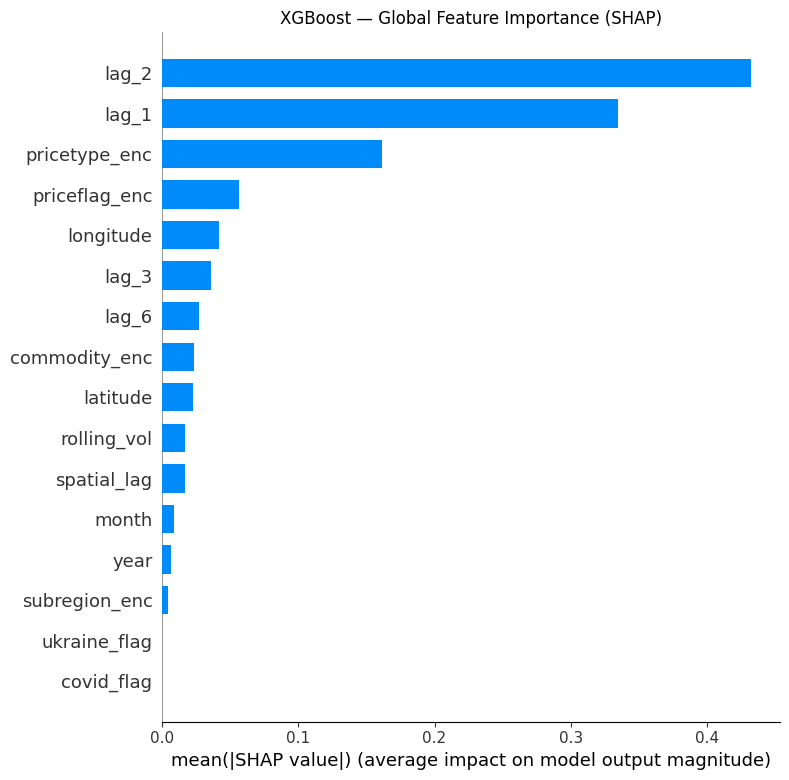

XGBoost SHAP plot saved.

Computing SHAP values for LightGBM regression...

LightGBM — Top 10 Features by Mean |SHAP|:
      feature  mean_abs_shap
        lag_2       0.419492
        lag_1       0.340170
pricetype_enc       0.163372
priceflag_enc       0.060130
    longitude       0.050343
        lag_6       0.042532
        lag_3       0.037001
commodity_enc       0.023195
     latitude       0.022889
  rolling_vol       0.021462


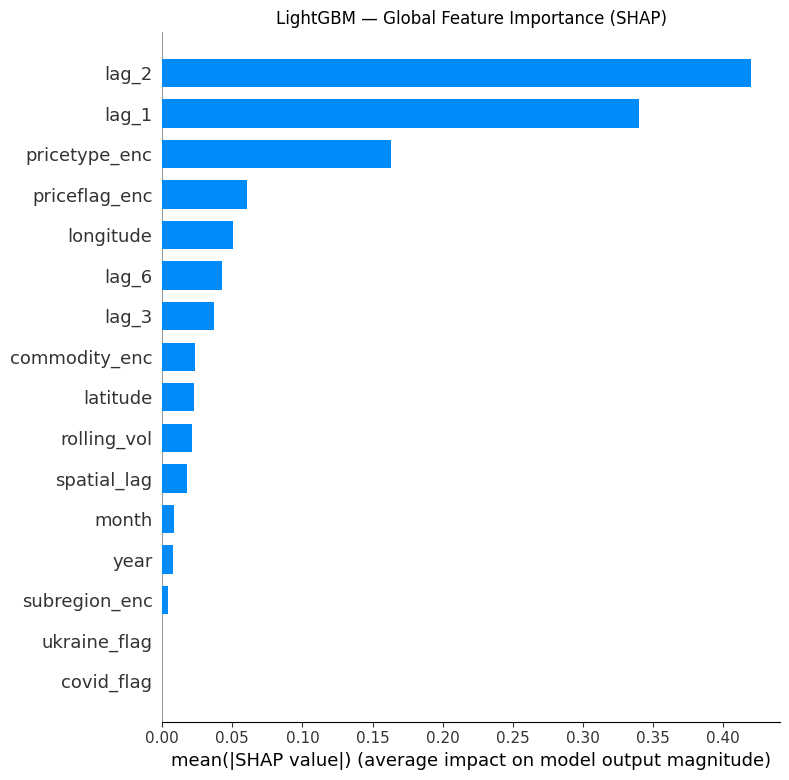

LightGBM SHAP plot saved.

Computing SHAP values for XGBoost spike classifier...

XGBoost Classifier — Top 10 Features by Mean |SHAP|:
      feature  mean_abs_shap
        lag_1       1.388433
  rolling_vol       1.057178
pricetype_enc       0.591206
     latitude       0.465117
    longitude       0.406748
        lag_2       0.329974
        month       0.252685
        lag_6       0.246963
        lag_3       0.236300
         year       0.153104


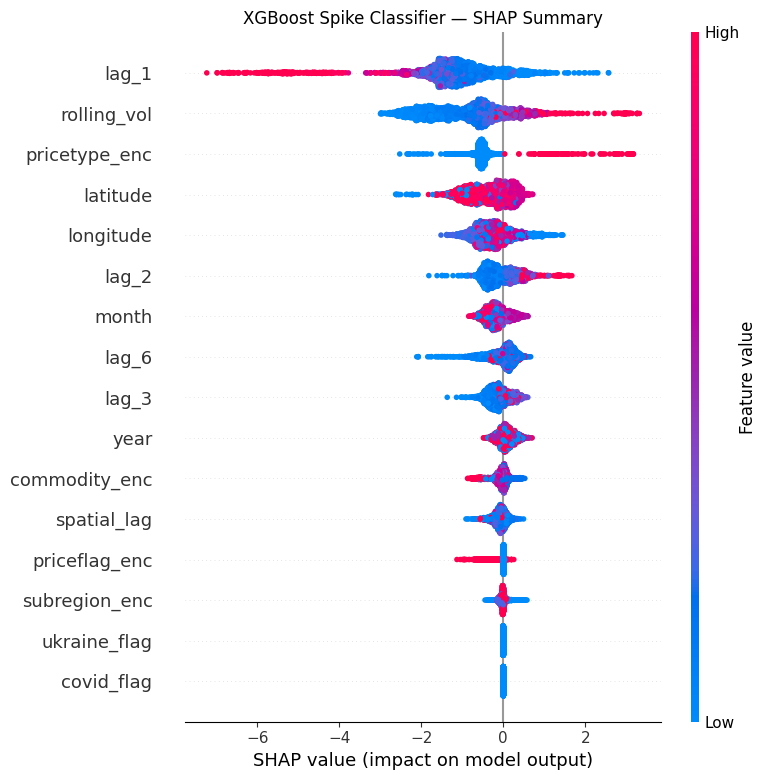

XGBoost classifier SHAP plot saved.

Cell 10 complete.


In [ ]:
# ============================================================
# CELL 10: SHAP feature importance — XGBoost and LightGBM
# ============================================================

import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FEATURE_NAMES = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_vol',
    'month', 'year', 'covid_flag', 'ukraine_flag',
    'latitude', 'longitude', 'subregion_enc', 'spatial_lag',
    'commodity_enc', 'pricetype_enc', 'priceflag_enc'
]

# ---- Use a sample of test set for SHAP (speed) ----
np.random.seed(RANDOM_SEED)
shap_sample_idx = np.random.choice(len(X_test), size=3000, replace=False)
X_shap = X_test[shap_sample_idx]

# ============================================================
# SHAP for XGBoost Regression
# ============================================================
print("Computing SHAP values for XGBoost regression...")
explainer_xgb = shap.TreeExplainer(xgb_reg)
shap_values_xgb = explainer_xgb.shap_values(X_shap)

# Mean absolute SHAP — global importance
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
shap_df_xgb = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_shap': mean_shap_xgb
}).sort_values('mean_abs_shap', ascending=False)

print("\nXGBoost — Top 10 Features by Mean |SHAP|:")
print(shap_df_xgb.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_shap,
                  feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False)
plt.title('XGBoost — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/THESIS/shap_xgb_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("XGBoost SHAP plot saved.")

# ============================================================
# SHAP for LightGBM Regression
# ============================================================
print("\nComputing SHAP values for LightGBM regression...")
explainer_lgb = shap.TreeExplainer(lgb_reg)
shap_values_lgb = explainer_lgb.shap_values(X_shap)

mean_shap_lgb = np.abs(shap_values_lgb).mean(axis=0)
shap_df_lgb = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_shap': mean_shap_lgb
}).sort_values('mean_abs_shap', ascending=False)

print("\nLightGBM — Top 10 Features by Mean |SHAP|:")
print(shap_df_lgb.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lgb, X_shap,
                  feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False)
plt.title('LightGBM — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/THESIS/shap_lgb_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("LightGBM SHAP plot saved.")

# ============================================================
# SHAP for XGBoost Spike Classifier
# ============================================================
print("\nComputing SHAP values for XGBoost spike classifier...")
explainer_xgb_clf = shap.TreeExplainer(xgb_clf)
shap_values_xgb_clf = explainer_xgb_clf.shap_values(X_shap)

mean_shap_xgb_clf = np.abs(shap_values_xgb_clf).mean(axis=0)
shap_df_xgb_clf = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_shap': mean_shap_xgb_clf
}).sort_values('mean_abs_shap', ascending=False)

print("\nXGBoost Classifier — Top 10 Features by Mean |SHAP|:")
print(shap_df_xgb_clf.head(10).to_string(index=False))

# Beeswarm plot for classifier
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb_clf, X_shap,
                  feature_names=FEATURE_NAMES,
                  show=False)
plt.title('XGBoost Spike Classifier — SHAP Summary')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/THESIS/shap_xgb_classifier.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("XGBoost classifier SHAP plot saved.")

# ---- Store SHAP dataframes ----
shap_results = {
    'xgb_reg': shap_df_xgb,
    'lgb_reg': shap_df_lgb,
    'xgb_clf': shap_df_xgb_clf
}

print("\nCell 10 complete.")

In [ ]:
# ============================================================
# CELL 11b: Fix ReduceLROnPlateau and retrain LSTM
# ============================================================

def train_lstm(model, train_loader, val_loader, n_epochs=100,
               lr=0.001, patience=15, pos_weight=31.0):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)  # removed verbose=False

    reg_criterion   = nn.MSELoss()
    class_criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    for epoch in range(n_epochs):
        # ---- Train ----
        model.train()
        train_loss = 0
        for X_batch, y_reg_batch, y_class_batch in train_loader:
            X_batch       = X_batch.to(device)
            y_reg_batch   = y_reg_batch.to(device)
            y_class_batch = y_class_batch.to(device)

            optimizer.zero_grad()
            reg_pred, class_pred = model(X_batch)

            loss_reg   = reg_criterion(reg_pred, y_reg_batch)
            loss_class = class_criterion(class_pred, y_class_batch)
            loss       = loss_reg + 0.3 * loss_class

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        # ---- Validate ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_reg_batch, y_class_batch in val_loader:
                X_batch       = X_batch.to(device)
                y_reg_batch   = y_reg_batch.to(device)
                y_class_batch = y_class_batch.to(device)
                reg_pred, class_pred = model(X_batch)
                loss_reg   = reg_criterion(reg_pred, y_reg_batch)
                loss_class = class_criterion(class_pred, y_class_batch)
                val_loss  += (loss_reg + 0.3 * loss_class).item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | "
                  f"Train loss: {train_loss/len(train_loader):.4f} | "
                  f"Val loss: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in
                                model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model

# ---- Reinitialise and retrain ----
torch.manual_seed(RANDOM_SEED)

lstm_model = LSTMPriceModel(
    input_size  = INPUT_SIZE,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.2
).to(device)

print("Training LSTM...")
lstm_model = train_lstm(
    lstm_model, train_loader, val_loader,
    n_epochs   = 100,
    lr         = 0.001,
    patience   = 15,
    pos_weight = scale_pos_weight
)

# ============================================================
# Evaluate LSTM on test set
# ============================================================
print("\nEvaluating LSTM on test set...")
lstm_model.eval()

all_reg_preds, all_class_probs = [], []
all_reg_true,  all_class_true  = [], []

with torch.no_grad():
    for X_batch, y_reg_batch, y_class_batch in test_loader:
        X_batch = X_batch.to(device)
        reg_pred, class_pred = lstm_model(X_batch)
        probs = torch.sigmoid(class_pred)
        all_reg_preds.extend(reg_pred.cpu().numpy())
        all_class_probs.extend(probs.cpu().numpy())
        all_reg_true.extend(y_reg_batch.numpy())
        all_class_true.extend(y_class_batch.numpy())

all_reg_preds   = np.array(all_reg_preds)
all_class_probs = np.array(all_class_probs)
all_reg_true    = np.array(all_reg_true)
all_class_true  = np.array(all_class_true)

# Regression metrics
y_pred_lstm_usd = np.exp(all_reg_preds)
y_true_lstm_usd = np.exp(all_reg_true)

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm_usd, y_pred_lstm_usd))
mae_lstm  = np.mean(np.abs(y_true_lstm_usd - y_pred_lstm_usd))
mape_lstm = mean_absolute_percentage_error(y_true_lstm_usd, y_pred_lstm_usd) * 100

# Classification — optimal threshold from validation set
val_class_probs = []
with torch.no_grad():
    for X_batch, _, y_class_batch in val_loader:
        X_batch = X_batch.to(device)
        _, class_pred = lstm_model(X_batch)
        probs = torch.sigmoid(class_pred)
        val_class_probs.extend(probs.cpu().numpy())

val_class_probs = np.array(val_class_probs)
prec, rec, thresh = precision_recall_curve(y_seq_class_val, val_class_probs)
f1_thresh        = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh_lstm = thresh[np.argmax(f1_thresh)]

y_pred_lstm_class = (all_class_probs >= best_thresh_lstm).astype(int)

f1_lstm      = f1_score(all_class_true, y_pred_lstm_class, zero_division=0)
auc_roc_lstm = roc_auc_score(all_class_true, all_class_probs)
auc_pr_lstm  = average_precision_score(all_class_true, all_class_probs)

print(f"\n=== LSTM RESULTS (Test 2023-2025) ===")
print(f"--- Regression ---")
print(f"RMSE : {rmse_lstm:.4f} USD")
print(f"MAE  : {mae_lstm:.4f} USD")
print(f"MAPE : {mape_lstm:.2f}%")
print(f"\n--- Spike Classification ---")
print(f"Threshold : {best_thresh_lstm:.4f}")
print(f"F1        : {f1_lstm:.4f}")
print(f"AUC-ROC   : {auc_roc_lstm:.4f}")
print(f"AUC-PR    : {auc_pr_lstm:.4f}")

# ---- Store results ----
results['LSTM'] = {
    'RMSE': rmse_lstm, 'MAE': mae_lstm, 'MAPE': mape_lstm,
    'F1': f1_lstm, 'AUC_ROC': auc_roc_lstm, 'AUC_PR': auc_pr_lstm
}

print("\nCell 11b complete.")

Training LSTM...
  Epoch  10 | Train loss: 0.7010 | Val loss: 0.9577
  Epoch  20 | Train loss: 0.6250 | Val loss: 0.8915
  Epoch  30 | Train loss: 0.5817 | Val loss: 0.8685
  Epoch  40 | Train loss: 0.6081 | Val loss: 0.8847
  Early stopping at epoch 49

Evaluating LSTM on test set...

=== LSTM RESULTS (Test 2023-2025) ===
--- Regression ---
RMSE : 6.2486 USD
MAE  : 1.5499 USD
MAPE : 31.09%

--- Spike Classification ---
Threshold : 0.9241
F1        : 0.3814
AUC-ROC   : 0.7857
AUC-PR    : 0.2787

Cell 11b complete.


In [ ]:
# ============================================================
# CELL 12: T-GCN — Temporal Graph Convolutional Network
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data, Batch
from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             f1_score, roc_auc_score, average_precision_score,
                             precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Building market integration graph...")

# ============================================================
# STEP 1: Build graph from TRAINING partition only (anti-leakage)
# ============================================================

CORR_THRESHOLD = 0.5
MIN_OVERLAP    = 24  # minimum months of overlap required

# Use training data only for graph construction
train_maize = train[train['commodity'].isin(['Maize'])].copy()
train_maize['market_uid'] = (train_maize['countryiso3'] + '_' +
                              train_maize['market'])

# Pivot to market x date matrix
price_pivot = train_maize.groupby(['market_uid', 'date'])['log_price']\
                          .mean().unstack(0)

# Compute correlation matrix
corr_matrix = price_pivot.corr(min_periods=MIN_OVERLAP)
market_uids = corr_matrix.columns.tolist()
n_markets   = len(market_uids)
print(f"Markets in graph: {n_markets}")

# Build edge list from correlation threshold
edge_src, edge_dst, edge_weights = [], [], []
for i in range(n_markets):
    for j in range(i+1, n_markets):
        c = corr_matrix.iloc[i, j]
        if not np.isnan(c) and c >= CORR_THRESHOLD:
            edge_src.append(i)
            edge_dst.append(j)
            edge_src.append(j)
            edge_dst.append(i)
            edge_weights.append(c)
            edge_weights.append(c)

edge_index  = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_weight = torch.tensor(edge_weights, dtype=torch.float32)

print(f"Edges above threshold {CORR_THRESHOLD}: {len(edge_src)//2:,}")
print(f"Graph density: {len(edge_src)/(n_markets*(n_markets-1))*100:.2f}%")

# ============================================================
# STEP 2: Build node feature sequences
# ============================================================

# Map market_uid to node index
market_to_idx = {uid: i for i, uid in enumerate(market_uids)}

# For each time step build node feature matrix
# Use all partitions but graph from training only
df_model['market_uid'] = df_model['countryiso3'] + '_' + df_model['market']

# Filter to graph markets only
df_graph = df_model[
    df_model['market_uid'].isin(market_uids) &
    df_model['commodity'].isin(['Maize'])
].copy()
df_graph['node_idx'] = df_graph['market_uid'].map(market_to_idx)
df_graph = df_graph.sort_values(['date', 'node_idx'])

print(f"\nGraph dataset records: {len(df_graph):,}")

# ============================================================
# STEP 3: T-GCN Architecture
# ============================================================

class TGCNCell(nn.Module):
    """One T-GCN cell: GCN spatial aggregation + GRU temporal update."""
    def __init__(self, input_size, hidden_size):
        super(TGCNCell, self).__init__()
        self.hidden_size = hidden_size
        self.gcn_r = GCNConv(input_size + hidden_size, hidden_size)
        self.gcn_u = GCNConv(input_size + hidden_size, hidden_size)
        self.gcn_c = GCNConv(input_size + hidden_size, hidden_size)

    def forward(self, x, h, edge_index, edge_weight=None):
        xh = torch.cat([x, h], dim=1)
        r  = torch.sigmoid(self.gcn_r(xh, edge_index, edge_weight))
        u  = torch.sigmoid(self.gcn_u(xh, edge_index, edge_weight))
        xrh = torch.cat([x, r * h], dim=1)
        c  = torch.tanh(self.gcn_c(xrh, edge_index, edge_weight))
        h_new = u * h + (1 - u) * c
        return h_new


class TGCNModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, seq_len=12):
        super(TGCNModel, self).__init__()
        self.hidden_size = hidden_size
        self.seq_len     = seq_len
        self.tgcn_cell   = TGCNCell(input_size, hidden_size)
        self.dropout      = nn.Dropout(0.2)
        self.reg_head     = nn.Linear(hidden_size, 1)
        self.class_head   = nn.Linear(hidden_size, 1)

    def forward(self, x_seq, edge_index, edge_weight, n_nodes):
        # x_seq: (T, N, F)
        h = torch.zeros(n_nodes, self.hidden_size).to(x_seq.device)
        for t in range(x_seq.size(0)):
            x_t = x_seq[t]  # (N, F)
            h   = self.tgcn_cell(x_t, h, edge_index, edge_weight)
        h = self.dropout(h)
        return self.reg_head(h).squeeze(-1), self.class_head(h).squeeze(-1)

# ============================================================
# STEP 4: Prepare T-GCN sequences
# ============================================================

def build_tgcn_sequences(df_part, market_to_idx, feature_cols,
                          target_reg, target_class, seq_len=12):
    """Build (date, node_matrix) sequences for T-GCN."""
    dates = sorted(df_part['date'].unique())
    X_sequences, y_reg_list, y_class_list, date_list = [], [], [], []

    # Build a date -> node feature matrix lookup
    date_node_feat  = {}
    date_node_reg   = {}
    date_node_class = {}

    for date, grp in df_part.groupby('date'):
        feat_mat  = np.zeros((len(market_to_idx), len(feature_cols)),
                              dtype=np.float32)
        reg_vec   = np.zeros(len(market_to_idx), dtype=np.float32)
        class_vec = np.zeros(len(market_to_idx), dtype=np.float32)
        for _, row in grp.iterrows():
            idx = row['node_idx']
            if not np.isnan(idx):
                idx = int(idx)
                feat_mat[idx]  = row[feature_cols].values.astype(np.float32)
                reg_vec[idx]   = row[target_reg]
                class_vec[idx] = row[target_class]
        date_node_feat[date]  = feat_mat
        date_node_reg[date]   = reg_vec
        date_node_class[date] = class_vec

    # Build sliding window sequences
    for i in range(seq_len, len(dates)):
        seq_dates = dates[i-seq_len:i]
        target_date = dates[i]
        if target_date not in date_node_feat:
            continue
        seq_feat = np.stack([date_node_feat[d] for d in seq_dates
                             if d in date_node_feat])
        if seq_feat.shape[0] < seq_len:
            continue
        X_sequences.append(seq_feat)      # (seq_len, N, F)
        y_reg_list.append(date_node_reg[target_date])
        y_class_list.append(date_node_class[target_date])
        date_list.append(target_date)

    return (np.array(X_sequences, dtype=np.float32),
            np.array(y_reg_list,   dtype=np.float32),
            np.array(y_class_list, dtype=np.float32),
            date_list)

print("\nBuilding T-GCN sequences (this may take 2-3 minutes)...")
SEQ_LEN = 12

X_tgcn_train, y_tgcn_reg_train, y_tgcn_class_train, dates_train = \
    build_tgcn_sequences(
        df_graph[df_graph['year'] <= 2019],
        market_to_idx, FEATURE_COLS, TARGET_REG, TARGET_CLASS, SEQ_LEN)

X_tgcn_val, y_tgcn_reg_val, y_tgcn_class_val, dates_val = \
    build_tgcn_sequences(
        df_graph[(df_graph['year'] >= 2020) & (df_graph['year'] <= 2022)],
        market_to_idx, FEATURE_COLS, TARGET_REG, TARGET_CLASS, SEQ_LEN)

X_tgcn_test, y_tgcn_reg_test, y_tgcn_class_test, dates_test = \
    build_tgcn_sequences(
        df_graph[df_graph['year'] >= 2023],
        market_to_idx, FEATURE_COLS, TARGET_REG, TARGET_CLASS, SEQ_LEN)

print(f"T-GCN sequences — Train: {X_tgcn_train.shape}, "
      f"Val: {X_tgcn_val.shape}, Test: {X_tgcn_test.shape}")

# ============================================================
# STEP 5: Train T-GCN
# ============================================================

n_nodes    = len(market_uids)
INPUT_SIZE = len(FEATURE_COLS)

tgcn_model = TGCNModel(
    input_size  = INPUT_SIZE,
    hidden_size = 64,
    seq_len     = SEQ_LEN
).to(device)

edge_index_dev  = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

optimizer_tgcn = torch.optim.Adam(tgcn_model.parameters(), lr=0.001)
reg_criterion  = nn.MSELoss()
class_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([scale_pos_weight]).to(device))

best_val_loss    = float('inf')
patience_counter = 0
best_state_tgcn  = None
PATIENCE         = 15
N_EPOCHS         = 80

print(f"\nTraining T-GCN ({n_nodes} nodes, {len(edge_src)//2} edges)...")

for epoch in range(N_EPOCHS):
    tgcn_model.train()
    train_loss = 0

    # Shuffle training sequences
    perm = np.random.permutation(len(X_tgcn_train))

    for i in perm:
        x_seq = torch.tensor(X_tgcn_train[i],
                              dtype=torch.float32).to(device)  # (T, N, F)
        y_r   = torch.tensor(y_tgcn_reg_train[i],
                              dtype=torch.float32).to(device)
        y_c   = torch.tensor(y_tgcn_class_train[i],
                              dtype=torch.float32).to(device)

        optimizer_tgcn.zero_grad()
        reg_pred, class_pred = tgcn_model(
            x_seq, edge_index_dev, edge_weight_dev, n_nodes)

        loss = reg_criterion(reg_pred, y_r) + \
               0.3 * class_criterion(class_pred, y_c)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tgcn_model.parameters(), 1.0)
        optimizer_tgcn.step()
        train_loss += loss.item()

    # Validate
    tgcn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for i in range(len(X_tgcn_val)):
            x_seq = torch.tensor(X_tgcn_val[i],
                                  dtype=torch.float32).to(device)
            y_r   = torch.tensor(y_tgcn_reg_val[i],
                                  dtype=torch.float32).to(device)
            y_c   = torch.tensor(y_tgcn_class_val[i],
                                  dtype=torch.float32).to(device)
            reg_pred, class_pred = tgcn_model(
                x_seq, edge_index_dev, edge_weight_dev, n_nodes)
            val_loss += (reg_criterion(reg_pred, y_r) +
                         0.3 * class_criterion(class_pred, y_c)).item()

    avg_val = val_loss / max(len(X_tgcn_val), 1)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | "
              f"Train: {train_loss/len(X_tgcn_train):.4f} | "
              f"Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0
        best_state_tgcn  = {k: v.clone() for k, v in
                             tgcn_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

tgcn_model.load_state_dict(best_state_tgcn)

# ============================================================
# STEP 6: Evaluate T-GCN
# ============================================================
print("\nEvaluating T-GCN on test set...")
tgcn_model.eval()

all_reg_true_tgcn,  all_reg_pred_tgcn  = [], []
all_class_true_tgcn, all_class_prob_tgcn = [], []

with torch.no_grad():
    for i in range(len(X_tgcn_test)):
        x_seq = torch.tensor(X_tgcn_test[i],
                              dtype=torch.float32).to(device)
        reg_pred, class_pred = tgcn_model(
            x_seq, edge_index_dev, edge_weight_dev, n_nodes)
        probs = torch.sigmoid(class_pred)

        all_reg_pred_tgcn.extend(reg_pred.cpu().numpy())
        all_class_prob_tgcn.extend(probs.cpu().numpy())
        all_reg_true_tgcn.extend(y_tgcn_reg_test[i])
        all_class_true_tgcn.extend(y_tgcn_class_test[i])

all_reg_pred_tgcn   = np.array(all_reg_pred_tgcn)
all_class_prob_tgcn = np.array(all_class_prob_tgcn)
all_reg_true_tgcn   = np.array(all_reg_true_tgcn)
all_class_true_tgcn = np.array(all_class_true_tgcn)

# Regression metrics
y_pred_tgcn_usd = np.exp(all_reg_pred_tgcn)
y_true_tgcn_usd = np.exp(all_reg_true_tgcn)

rmse_tgcn = np.sqrt(mean_squared_error(y_true_tgcn_usd, y_pred_tgcn_usd))
mae_tgcn  = np.mean(np.abs(y_true_tgcn_usd - y_pred_tgcn_usd))
mape_tgcn = mean_absolute_percentage_error(
    y_true_tgcn_usd, y_pred_tgcn_usd) * 100

# Optimal threshold from validation
val_class_prob_tgcn = []
with torch.no_grad():
    for i in range(len(X_tgcn_val)):
        x_seq = torch.tensor(X_tgcn_val[i],
                              dtype=torch.float32).to(device)
        _, class_pred = tgcn_model(
            x_seq, edge_index_dev, edge_weight_dev, n_nodes)
        probs = torch.sigmoid(class_pred)
        val_class_prob_tgcn.extend(probs.cpu().numpy())

val_class_prob_tgcn = np.array(val_class_prob_tgcn)
y_val_flat = y_tgcn_class_val.flatten()
prec, rec, thresh = precision_recall_curve(y_val_flat, val_class_prob_tgcn)
f1_thr  = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh_tgcn = thresh[np.argmax(f1_thr)]

y_pred_tgcn_class = (all_class_prob_tgcn >= best_thresh_tgcn).astype(int)

f1_tgcn      = f1_score(all_class_true_tgcn, y_pred_tgcn_class, zero_division=0)
auc_roc_tgcn = roc_auc_score(all_class_true_tgcn, all_class_prob_tgcn)
auc_pr_tgcn  = average_precision_score(all_class_true_tgcn, all_class_prob_tgcn)

print(f"\n=== T-GCN RESULTS (Test 2023-2025) ===")
print(f"--- Regression ---")
print(f"RMSE : {rmse_tgcn:.4f} USD")
print(f"MAE  : {mae_tgcn:.4f} USD")
print(f"MAPE : {mape_tgcn:.2f}%")
print(f"\n--- Spike Classification ---")
print(f"Threshold : {best_thresh_tgcn:.4f}")
print(f"F1        : {f1_tgcn:.4f}")
print(f"AUC-ROC   : {auc_roc_tgcn:.4f}")
print(f"AUC-PR    : {auc_pr_tgcn:.4f}")

# ---- Store results ----
results['TGCN'] = {
    'RMSE': rmse_tgcn, 'MAE': mae_tgcn, 'MAPE': mape_tgcn,
    'F1': f1_tgcn, 'AUC_ROC': auc_roc_tgcn, 'AUC_PR': auc_pr_tgcn
}

print("\nCell 12 complete.")

Building market integration graph...
Markets in graph: 1046
Edges above threshold 0.5: 25,340
Graph density: 4.64%

Graph dataset records: 70,400

Building T-GCN sequences (this may take 2-3 minutes)...
T-GCN sequences — Train: (48, 12, 1046, 16), Val: (24, 12, 1046, 16), Test: (24, 12, 1046, 16)

Training T-GCN (1046 nodes, 25340 edges)...
  Epoch  10 | Train: 1.4155 | Val: 1.1532
  Epoch  20 | Train: 1.2544 | Val: 1.0935
  Epoch  30 | Train: 1.2367 | Val: 1.0750
  Epoch  40 | Train: 1.2260 | Val: 1.1002
  Epoch  50 | Train: 1.2322 | Val: 1.0280
  Epoch  60 | Train: 1.2119 | Val: 1.0864
  Early stopping at epoch 65

Evaluating T-GCN on test set...

=== T-GCN RESULTS (Test 2023-2025) ===
--- Regression ---
RMSE : 8.4308 USD
MAE  : 2.0703 USD
MAPE : 50.66%

--- Spike Classification ---
Threshold : 0.5682
F1        : 0.0529
AUC-ROC   : 0.6368
AUC-PR    : 0.0213

Cell 12 complete.


In [ ]:
# ============================================================
# CELL 13: Bootstrap 95% CI on all headline metrics
# ============================================================

from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             f1_score, roc_auc_score, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_SEED)
N_BOOTSTRAP = 10000

def bootstrap_regression_metrics(y_true, y_pred, n_bootstrap=10000):
    """Bootstrap CI for RMSE, MAE, MAPE."""
    rmses, maes, mapes = [], [], []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        rmses.append(np.sqrt(mean_squared_error(yt, yp)))
        maes.append(np.mean(np.abs(yt - yp)))
        mapes.append(mean_absolute_percentage_error(yt, yp) * 100)
    return {
        'RMSE': (np.percentile(rmses, 2.5), np.percentile(rmses, 97.5)),
        'MAE':  (np.percentile(maes,  2.5), np.percentile(maes,  97.5)),
        'MAPE': (np.percentile(mapes, 2.5), np.percentile(mapes, 97.5))
    }

def bootstrap_classification_metrics(y_true, y_prob, y_pred, n_bootstrap=10000):
    """Bootstrap CI for F1, AUC-ROC, AUC-PR."""
    f1s, aucs, prs = [], [], []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        f1s.append(f1_score(yt, yp, zero_division=0))
        aucs.append(roc_auc_score(yt, ypr))
        prs.append(average_precision_score(yt, ypr))
    return {
        'F1':      (np.percentile(f1s,  2.5), np.percentile(f1s,  97.5)),
        'AUC_ROC': (np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)),
        'AUC_PR':  (np.percentile(prs,  2.5), np.percentile(prs,  97.5))
    }

print("Computing bootstrap CIs (10,000 iterations each)...")
print("This will take several minutes...\n")

ci_results = {}

# ---- SARIMA ----
print("SARIMA...")
y_true_sarima = sarima_df['y_true_usd'].values
y_pred_sarima = sarima_df['y_pred_usd_sarima'].values
ci_results['SARIMA'] = bootstrap_regression_metrics(
    y_true_sarima, y_pred_sarima, N_BOOTSTRAP)

# ---- Panel FE ----
print("Panel FE...")
y_true_fe  = np.exp(test[TARGET_REG].values)
y_pred_fe  = np.exp(ridge.predict(X_test_fe))
y_prob_fe  = test_fe_df['pred_pct_change'].clip(-1000,1000).values
y_class_fe = test_fe_df['spike_pred_fe'].values
y_true_class_fe = test_fe_df['spike'].values
ci_reg_fe  = bootstrap_regression_metrics(y_true_fe, y_pred_fe, N_BOOTSTRAP)
ci_clf_fe  = bootstrap_classification_metrics(
    y_true_class_fe, y_prob_fe, y_class_fe, N_BOOTSTRAP)
ci_results['Panel_FE'] = {**ci_reg_fe, **ci_clf_fe}

# ---- XGBoost ----
print("XGBoost...")
y_true_xgb_usd = np.exp(y_test_reg)
ci_reg_xgb = bootstrap_regression_metrics(
    y_true_xgb_usd, y_pred_xgb_usd, N_BOOTSTRAP)
ci_clf_xgb = bootstrap_classification_metrics(
    y_test_class, y_prob_xgb, y_pred_xgb_class_opt, N_BOOTSTRAP)
ci_results['XGBoost'] = {**ci_reg_xgb, **ci_clf_xgb}

# ---- LightGBM ----
print("LightGBM...")
ci_reg_lgb = bootstrap_regression_metrics(
    y_true_xgb_usd, y_pred_lgb_usd, N_BOOTSTRAP)
ci_clf_lgb = bootstrap_classification_metrics(
    y_test_class, y_prob_lgb, y_pred_lgb_class_opt, N_BOOTSTRAP)
ci_results['LightGBM'] = {**ci_reg_lgb, **ci_clf_lgb}

# ---- LSTM ----
print("LSTM...")
ci_reg_lstm = bootstrap_regression_metrics(
    y_true_lstm_usd, y_pred_lstm_usd, N_BOOTSTRAP)
ci_clf_lstm = bootstrap_classification_metrics(
    all_class_true, all_class_probs, y_pred_lstm_class, N_BOOTSTRAP)
ci_results['LSTM'] = {**ci_reg_lstm, **ci_clf_lstm}

# ---- T-GCN ----
print("T-GCN...")
ci_reg_tgcn = bootstrap_regression_metrics(
    y_true_tgcn_usd, y_pred_tgcn_usd, N_BOOTSTRAP)
ci_clf_tgcn = bootstrap_classification_metrics(
    all_class_true_tgcn, all_class_prob_tgcn,
    y_pred_tgcn_class, N_BOOTSTRAP)
ci_results['TGCN'] = {**ci_reg_tgcn, **ci_clf_tgcn}

# ---- Print all CIs ----
print("\n=== BOOTSTRAP 95% CONFIDENCE INTERVALS ===\n")
for model, cis in ci_results.items():
    print(f"--- {model} ---")
    for metric, (lo, hi) in cis.items():
        print(f"  {metric}: [{lo:.4f}, {hi:.4f}]")
    print()

print("Cell 13 complete.")

Computing bootstrap CIs (10,000 iterations each)...
This will take several minutes...

SARIMA...
Panel FE...
XGBoost...
LightGBM...
LSTM...
T-GCN...

=== BOOTSTRAP 95% CONFIDENCE INTERVALS ===

--- SARIMA ---
  RMSE: [11.1237, 16.2362]
  MAE: [2.4525, 2.7617]
  MAPE: [48.2280, 50.1270]

--- Panel_FE ---
  RMSE: [10.0108, 10.3857]
  MAE: [2.6256, 2.7507]
  MAPE: [40.8636, 42.2291]
  F1: [0.3931, 0.4249]
  AUC_ROC: [0.7136, 0.7386]
  AUC_PR: [0.3561, 0.3939]

--- XGBoost ---
  RMSE: [8.4602, 8.8170]
  MAE: [1.8495, 1.9570]
  MAPE: [16.4748, 17.0634]
  F1: [0.4638, 0.5014]
  AUC_ROC: [0.8293, 0.8463]
  AUC_PR: [0.4759, 0.5102]

--- LightGBM ---
  RMSE: [8.0476, 8.4002]
  MAE: [1.7514, 1.8530]
  MAPE: [16.4102, 17.0038]
  F1: [0.4437, 0.4804]
  AUC_ROC: [0.8289, 0.8440]
  AUC_PR: [0.3590, 0.3963]

--- LSTM ---
  RMSE: [6.0514, 6.4477]
  MAE: [1.4952, 1.6059]
  MAPE: [30.4917, 31.7442]
  F1: [0.3462, 0.4156]
  AUC_ROC: [0.7682, 0.8029]
  AUC_PR: [0.2430, 0.3155]

--- TGCN ---
  RMSE: [8.059

In [ ]:
# ============================================================
# CELL 14: Diebold-Mariano pairwise model comparison tests
# ============================================================

from scipy import stats
import itertools
import warnings
warnings.filterwarnings('ignore')

def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1):
    """
    Diebold-Mariano test for equal predictive accuracy.
    H0: both models have equal MSE.
    Returns test statistic and p-value.
    Negative DM stat means model 1 is better (lower error).
    """
    e1 = (y_true - y_pred1) ** 2
    e2 = (y_true - y_pred2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_mean = np.mean(d)

    # Newey-West variance estimator
    gamma0 = np.var(d, ddof=1)
    gammas = [np.cov(d[h:], d[:-h])[0, 1] for h in range(1, h+1)]
    var_d  = (gamma0 + 2 * sum(gammas)) / n
    var_d  = max(var_d, 1e-10)  # prevent division by zero

    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# ---- Align all predictions to same test observations ----
# Use the main test set (gradient boosting models) as reference
# SARIMA covers a subset — use its subset for SARIMA comparisons

print("=== DIEBOLD-MARIANO TESTS (Test Set 2023-2025) ===")
print("H0: equal predictive accuracy | * p<0.05 | ** p<0.01 | *** p<0.001\n")

# Predictions dictionary (on full test set)
y_true_full = np.exp(y_test_reg)

preds_full = {
    'Panel_FE': y_pred_fe_usd,
    'XGBoost':  y_pred_xgb_usd,
    'LightGBM': y_pred_lgb_usd,
    'LSTM':     y_pred_lstm_usd[:len(y_true_full)]
                if len(y_pred_lstm_usd) >= len(y_true_full)
                else y_pred_lstm_usd,
}

# Align lengths
min_len = min(len(y_true_full),
              min(len(v) for v in preds_full.values()))
y_true_dm = y_true_full[:min_len]
preds_aligned = {k: v[:min_len] for k, v in preds_full.items()}

# All pairwise combinations
models = list(preds_aligned.keys())
dm_results = []

for m1, m2 in itertools.combinations(models, 2):
    dm_stat, p_val = diebold_mariano_test(
        y_true_dm,
        preds_aligned[m1],
        preds_aligned[m2]
    )
    stars = ''
    if p_val < 0.001: stars = '***'
    elif p_val < 0.01: stars = '**'
    elif p_val < 0.05: stars = '*'

    better = m1 if dm_stat < 0 else m2
    dm_results.append({
        'Model 1': m1,
        'Model 2': m2,
        'DM Stat': dm_stat,
        'p-value': p_val,
        'Sig':     stars,
        'Better':  better
    })
    print(f"{m1} vs {m2}:")
    print(f"  DM stat={dm_stat:.4f}, p={p_val:.4f}{stars} "
          f"→ {better} is better")

dm_df = pd.DataFrame(dm_results)

# ---- Also run SARIMA vs all on SARIMA subset ----
print(f"\n--- SARIMA comparisons (subset of {len(sarima_df)} rows) ---")

# Get matching predictions for SARIMA subset
sarima_test = sarima_df.copy()
sarima_test = sarima_test.merge(
    test[['countryiso3','market','commodity','date']].assign(
        xgb_pred=y_pred_xgb_usd,
        lgb_pred=y_pred_lgb_usd
    ),
    on=['countryiso3','market','commodity','date'],
    how='inner'
)

if len(sarima_test) > 100:
    yt_s = sarima_test['y_true_usd'].values
    yp_sarima = sarima_test['y_pred_usd_sarima'].values

    for mname, col in [('XGBoost','xgb_pred'), ('LightGBM','lgb_pred')]:
        if col in sarima_test.columns:
            yp_ml = sarima_test[col].values
            dm_stat, p_val = diebold_mariano_test(yt_s, yp_sarima, yp_ml)
            stars = ''
            if p_val < 0.001: stars = '***'
            elif p_val < 0.01: stars = '**'
            elif p_val < 0.05: stars = '*'
            better = 'SARIMA' if dm_stat < 0 else mname
            print(f"SARIMA vs {mname}: DM={dm_stat:.4f}, "
                  f"p={p_val:.4f}{stars} → {better} is better")

print("\nCell 14 complete.")

=== DIEBOLD-MARIANO TESTS (Test Set 2023-2025) ===
H0: equal predictive accuracy | * p<0.05 | ** p<0.01 | *** p<0.001

Panel_FE vs XGBoost:
  DM stat=22.5284, p=0.0000*** → XGBoost is better
Panel_FE vs LightGBM:
  DM stat=22.3562, p=0.0000*** → LightGBM is better
Panel_FE vs LSTM:
  DM stat=-41.1969, p=0.0000*** → Panel_FE is better
XGBoost vs LightGBM:
  DM stat=11.0894, p=0.0000*** → LightGBM is better
XGBoost vs LSTM:
  DM stat=-40.1516, p=0.0000*** → XGBoost is better
LightGBM vs LSTM:
  DM stat=-38.9889, p=0.0000*** → LightGBM is better

--- SARIMA comparisons (subset of 27450 rows) ---
SARIMA vs XGBoost: DM=1.7515, p=0.0799 → XGBoost is better
SARIMA vs LightGBM: DM=1.7984, p=0.0721 → LightGBM is better

Cell 14 complete.


Computing walk-forward validation curves...


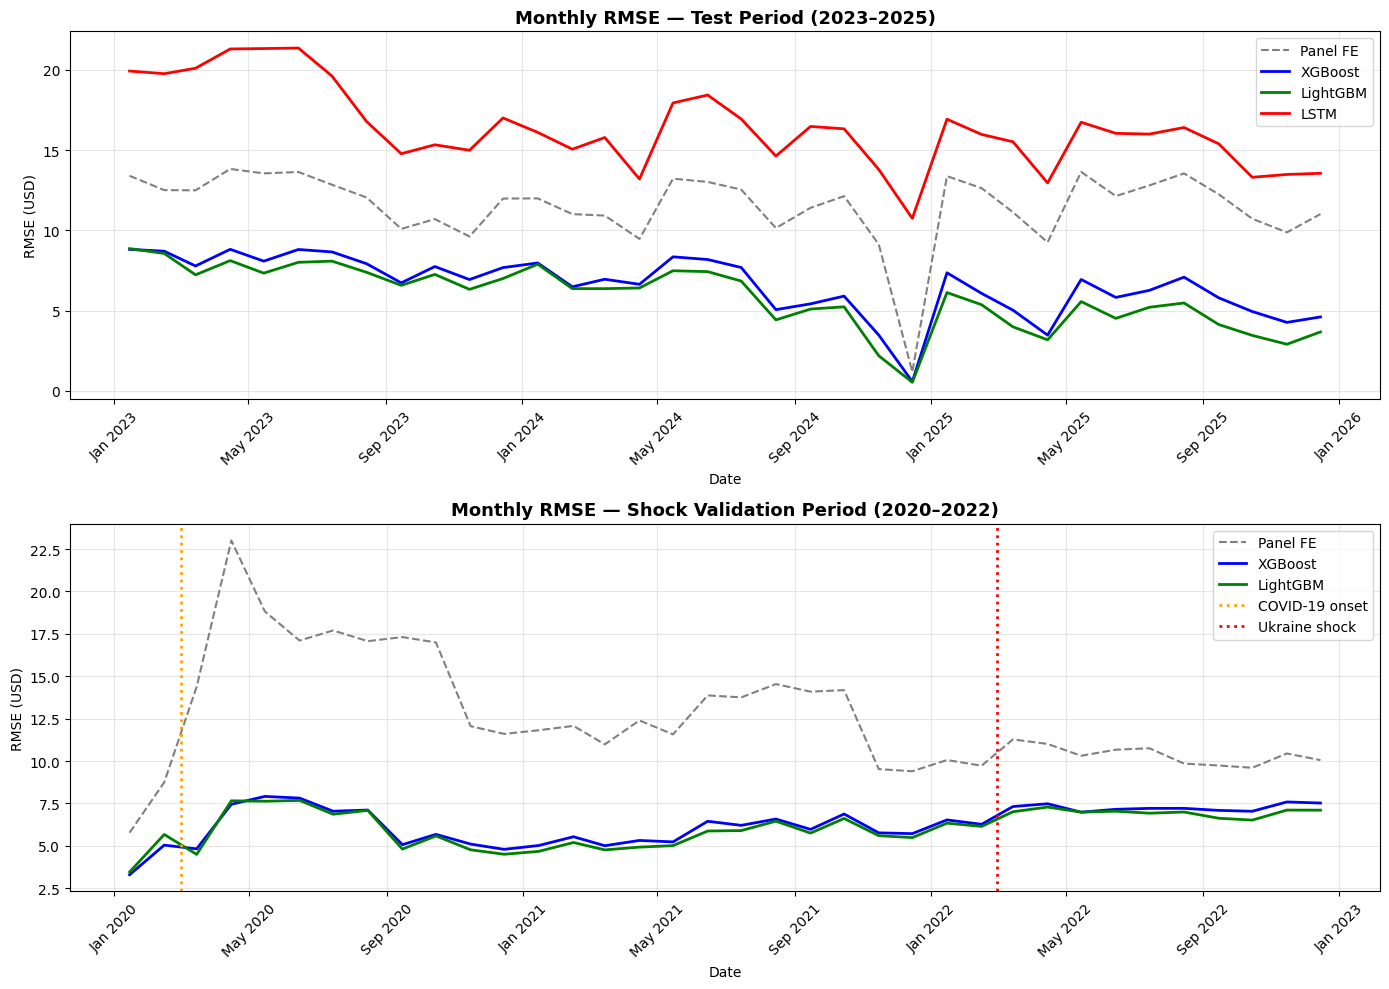

Walk-forward curves saved.

=== MEAN MONTHLY RMSE BY PERIOD ===
Model          Test 2023-25    Val 2020-22
------------------------------------------
Panel FE            11.5348        12.5641
XGBoost              6.5867         6.2864
LightGBM             5.8526         6.0734
LSTM                16.3871            N/A

Cell 15 complete.


In [ ]:
# ============================================================
# CELL 15: Walk-forward validation curves (fixed)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

print("Computing walk-forward validation curves...")

# ---- Build val FE matrix the same way as test ----
val_fe_raw = pd.get_dummies(val['fe_id'], prefix='fe', sparse=True)
val_fe_raw, _ = val_fe_raw.align(
    pd.get_dummies(train['fe_id'], prefix='fe', sparse=True),
    join='right', axis=1, fill_value=0)

import scipy.sparse as sp
X_val_fe_matrix = sp.hstack([
    sp.csr_matrix(val[FE_FEATURES].fillna(0).values),
    val_fe_raw.values
])

# ---- Test set predictions ----
test_dated = test.copy()
test_dated['y_true_usd']  = np.exp(y_test_reg)
test_dated['y_pred_fe']   = y_pred_fe_usd[:len(test_dated)]
test_dated['y_pred_xgb']  = y_pred_xgb_usd[:len(test_dated)]
test_dated['y_pred_lgb']  = y_pred_lgb_usd[:len(test_dated)]

lstm_test_len = min(len(y_pred_lstm_usd), len(test_dated))
test_dated = test_dated.iloc[:lstm_test_len].copy()
test_dated['y_pred_lstm'] = y_pred_lstm_usd[:lstm_test_len]

# ---- Val set predictions ----
val_dated = val.copy()
val_dated['y_true_usd']  = np.exp(y_val_reg)
val_dated['y_pred_fe']   = np.exp(ridge.predict(X_val_fe_matrix))
val_dated['y_pred_xgb']  = np.exp(xgb_reg.predict(X_val))
val_dated['y_pred_lgb']  = np.exp(lgb_reg.predict(X_val))

# ---- Monthly RMSE function ----
def monthly_rmse(df, pred_col, true_col='y_true_usd'):
    return df.groupby('date').apply(
        lambda g: np.sqrt(mean_squared_error(g[true_col], g[pred_col]))
        if len(g) > 1 else np.nan
    ).reset_index(name='rmse')

# ---- Compute monthly RMSE ----
rmse_fe   = monthly_rmse(test_dated, 'y_pred_fe')
rmse_xgb  = monthly_rmse(test_dated, 'y_pred_xgb')
rmse_lgb  = monthly_rmse(test_dated, 'y_pred_lgb')
rmse_lstm = monthly_rmse(test_dated, 'y_pred_lstm')

rmse_fe_val  = monthly_rmse(val_dated, 'y_pred_fe')
rmse_xgb_val = monthly_rmse(val_dated, 'y_pred_xgb')
rmse_lgb_val = monthly_rmse(val_dated, 'y_pred_lgb')

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Test period
ax1 = axes[0]
ax1.plot(rmse_fe['date'],   rmse_fe['rmse'],
         label='Panel FE',  color='gray',  linewidth=1.5, linestyle='--')
ax1.plot(rmse_xgb['date'],  rmse_xgb['rmse'],
         label='XGBoost',   color='blue',  linewidth=2)
ax1.plot(rmse_lgb['date'],  rmse_lgb['rmse'],
         label='LightGBM',  color='green', linewidth=2)
ax1.plot(rmse_lstm['date'], rmse_lstm['rmse'],
         label='LSTM',      color='red',   linewidth=2)
ax1.set_title('Monthly RMSE — Test Period (2023–2025)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('RMSE (USD)')
ax1.set_xlabel('Date')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Shock validation period
ax2 = axes[1]
ax2.plot(rmse_fe_val['date'],  rmse_fe_val['rmse'],
         label='Panel FE',  color='gray',  linewidth=1.5, linestyle='--')
ax2.plot(rmse_xgb_val['date'], rmse_xgb_val['rmse'],
         label='XGBoost',   color='blue',  linewidth=2)
ax2.plot(rmse_lgb_val['date'], rmse_lgb_val['rmse'],
         label='LightGBM',  color='green', linewidth=2)
ax2.axvline(pd.Timestamp('2020-03-01'), color='orange',
            linestyle=':', linewidth=2, label='COVID-19 onset')
ax2.axvline(pd.Timestamp('2022-03-01'), color='red',
            linestyle=':', linewidth=2, label='Ukraine shock')
ax2.set_title('Monthly RMSE — Shock Validation Period (2020–2022)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('RMSE (USD)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/THESIS/walkforward_rmse_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Walk-forward curves saved.")

# ---- Summary statistics ----
print("\n=== MEAN MONTHLY RMSE BY PERIOD ===")
print(f"{'Model':<12} {'Test 2023-25':>14} {'Val 2020-22':>14}")
print("-" * 42)
print(f"{'Panel FE':<12} "
      f"{rmse_fe['rmse'].mean():>14.4f} "
      f"{rmse_fe_val['rmse'].mean():>14.4f}")
print(f"{'XGBoost':<12} "
      f"{rmse_xgb['rmse'].mean():>14.4f} "
      f"{rmse_xgb_val['rmse'].mean():>14.4f}")
print(f"{'LightGBM':<12} "
      f"{rmse_lgb['rmse'].mean():>14.4f} "
      f"{rmse_lgb_val['rmse'].mean():>14.4f}")
print(f"{'LSTM':<12} "
      f"{rmse_lstm['rmse'].mean():>14.4f} "
      f"{'N/A':>14}")

print("\nCell 15 complete.")

In [ ]:
# ============================================================
# CELL 16: Multi-seed reliability — LSTM and T-GCN
# ============================================================

from sklearn.metrics import (mean_squared_error, mean_absolute_percentage_error,
                             f1_score, roc_auc_score, average_precision_score,
                             precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

SEEDS = [42, 123, 256, 789, 1024]

# ============================================================
# LSTM multi-seed
# ============================================================
print("=== LSTM MULTI-SEED RELIABILITY (5 seeds) ===\n")

lstm_seed_results = []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_s = LSTMPriceModel(
        input_size  = INPUT_SIZE,
        hidden_size = 128,
        num_layers  = 2,
        dropout     = 0.2
    ).to(device)

    model_s = train_lstm(
        model_s, train_loader, val_loader,
        n_epochs   = 100,
        lr         = 0.001,
        patience   = 15,
        pos_weight = scale_pos_weight
    )

    # Evaluate
    model_s.eval()
    reg_preds, class_probs = [], []
    reg_true,  class_true  = [], []

    with torch.no_grad():
        for X_batch, y_reg_batch, y_class_batch in test_loader:
            X_batch = X_batch.to(device)
            rp, cp  = model_s(X_batch)
            probs   = torch.sigmoid(cp)
            reg_preds.extend(rp.cpu().numpy())
            class_probs.extend(probs.cpu().numpy())
            reg_true.extend(y_reg_batch.numpy())
            class_true.extend(y_class_batch.numpy())

    reg_preds   = np.array(reg_preds)
    class_probs = np.array(class_probs)
    reg_true    = np.array(reg_true)
    class_true  = np.array(class_true)

    y_pred_usd = np.exp(reg_preds)
    y_true_usd = np.exp(reg_true)

    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mae  = np.mean(np.abs(y_true_usd - y_pred_usd))
    mape = mean_absolute_percentage_error(y_true_usd, y_pred_usd) * 100

    # Optimal threshold from val
    val_probs = []
    with torch.no_grad():
        for X_batch, _, yc in val_loader:
            X_batch = X_batch.to(device)
            _, cp   = model_s(X_batch)
            val_probs.extend(torch.sigmoid(cp).cpu().numpy())
    val_probs = np.array(val_probs)
    prec, rec, thr = precision_recall_curve(y_seq_class_val, val_probs)
    f1t = 2*(prec*rec)/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1t)]

    y_pred_class = (class_probs >= best_thr).astype(int)
    f1      = f1_score(class_true, y_pred_class, zero_division=0)
    auc_roc = roc_auc_score(class_true, class_probs)
    auc_pr  = average_precision_score(class_true, class_probs)

    lstm_seed_results.append({
        'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'MAPE': mape, 'F1': f1,
        'AUC_ROC': auc_roc, 'AUC_PR': auc_pr
    })
    print(f"Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, "
          f"MAPE={mape:.2f}%, F1={f1:.4f}, AUC-ROC={auc_roc:.4f}")

lstm_seed_df = pd.DataFrame(lstm_seed_results)
print(f"\nLSTM across 5 seeds:")
print(f"  RMSE  — mean={lstm_seed_df['RMSE'].mean():.4f}, "
      f"std={lstm_seed_df['RMSE'].std():.4f}")
print(f"  MAE   — mean={lstm_seed_df['MAE'].mean():.4f}, "
      f"std={lstm_seed_df['MAE'].std():.4f}")
print(f"  MAPE  — mean={lstm_seed_df['MAPE'].mean():.2f}%, "
      f"std={lstm_seed_df['MAPE'].std():.2f}%")
print(f"  F1    — mean={lstm_seed_df['F1'].mean():.4f}, "
      f"std={lstm_seed_df['F1'].std():.4f}")
print(f"  AUC-ROC — mean={lstm_seed_df['AUC_ROC'].mean():.4f}, "
      f"std={lstm_seed_df['AUC_ROC'].std():.4f}")

# ============================================================
# T-GCN multi-seed
# ============================================================
print("\n=== T-GCN MULTI-SEED RELIABILITY (5 seeds) ===\n")

tgcn_seed_results = []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_t = TGCNModel(
        input_size  = INPUT_SIZE,
        hidden_size = 64,
        seq_len     = SEQ_LEN
    ).to(device)

    optimizer_t  = torch.optim.Adam(model_t.parameters(), lr=0.001)
    reg_crit     = nn.MSELoss()
    class_crit   = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([scale_pos_weight]).to(device))

    best_val  = float('inf')
    pat_count = 0
    best_st   = None

    for epoch in range(80):
        model_t.train()
        perm = np.random.permutation(len(X_tgcn_train))
        for i in perm:
            xs = torch.tensor(X_tgcn_train[i],
                              dtype=torch.float32).to(device)
            yr = torch.tensor(y_tgcn_reg_train[i],
                              dtype=torch.float32).to(device)
            yc = torch.tensor(y_tgcn_class_train[i],
                              dtype=torch.float32).to(device)
            optimizer_t.zero_grad()
            rp, cp = model_t(xs, edge_index_dev, edge_weight_dev, n_nodes)
            loss = reg_crit(rp, yr) + 0.3 * class_crit(cp, yc)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_t.parameters(), 1.0)
            optimizer_t.step()

        model_t.eval()
        vl = 0
        with torch.no_grad():
            for i in range(len(X_tgcn_val)):
                xs = torch.tensor(X_tgcn_val[i],
                                  dtype=torch.float32).to(device)
                yr = torch.tensor(y_tgcn_reg_val[i],
                                  dtype=torch.float32).to(device)
                yc = torch.tensor(y_tgcn_class_val[i],
                                  dtype=torch.float32).to(device)
                rp, cp = model_t(xs, edge_index_dev, edge_weight_dev, n_nodes)
                vl += (reg_crit(rp, yr) + 0.3*class_crit(cp, yc)).item()
        avg_vl = vl / max(len(X_tgcn_val), 1)

        if avg_vl < best_val:
            best_val  = avg_vl
            pat_count = 0
            best_st   = {k: v.clone() for k, v in model_t.state_dict().items()}
        else:
            pat_count += 1
            if pat_count >= 15:
                break

    model_t.load_state_dict(best_st)
    model_t.eval()

    rp_all, cp_all, rt_all, ct_all = [], [], [], []
    with torch.no_grad():
        for i in range(len(X_tgcn_test)):
            xs = torch.tensor(X_tgcn_test[i],
                              dtype=torch.float32).to(device)
            rp, cp = model_t(xs, edge_index_dev, edge_weight_dev, n_nodes)
            probs  = torch.sigmoid(cp)
            rp_all.extend(rp.cpu().numpy())
            cp_all.extend(probs.cpu().numpy())
            rt_all.extend(y_tgcn_reg_test[i])
            ct_all.extend(y_tgcn_class_test[i])

    rp_all = np.array(rp_all)
    cp_all = np.array(cp_all)
    rt_all = np.array(rt_all)
    ct_all = np.array(ct_all)

    y_pred_usd_t = np.exp(rp_all)
    y_true_usd_t = np.exp(rt_all)

    rmse = np.sqrt(mean_squared_error(y_true_usd_t, y_pred_usd_t))
    mae  = np.mean(np.abs(y_true_usd_t - y_pred_usd_t))
    mape = mean_absolute_percentage_error(y_true_usd_t, y_pred_usd_t) * 100

    # Optimal threshold
    vcp = []
    with torch.no_grad():
        for i in range(len(X_tgcn_val)):
            xs = torch.tensor(X_tgcn_val[i],
                              dtype=torch.float32).to(device)
            _, cp = model_t(xs, edge_index_dev, edge_weight_dev, n_nodes)
            vcp.extend(torch.sigmoid(cp).cpu().numpy())
    vcp = np.array(vcp)
    yv  = y_tgcn_class_val.flatten()
    prec, rec, thr = precision_recall_curve(yv, vcp)
    f1t = 2*(prec*rec)/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1t)]

    ypc = (cp_all >= best_thr).astype(int)
    f1      = f1_score(ct_all, ypc, zero_division=0)
    auc_roc = roc_auc_score(ct_all, cp_all)
    auc_pr  = average_precision_score(ct_all, cp_all)

    tgcn_seed_results.append({
        'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'MAPE': mape, 'F1': f1,
        'AUC_ROC': auc_roc, 'AUC_PR': auc_pr
    })
    print(f"Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, "
          f"MAPE={mape:.2f}%, F1={f1:.4f}, AUC-ROC={auc_roc:.4f}")

tgcn_seed_df = pd.DataFrame(tgcn_seed_results)
print(f"\nT-GCN across 5 seeds:")
print(f"  RMSE  — mean={tgcn_seed_df['RMSE'].mean():.4f}, "
      f"std={tgcn_seed_df['RMSE'].std():.4f}")
print(f"  MAE   — mean={tgcn_seed_df['MAE'].mean():.4f}, "
      f"std={tgcn_seed_df['MAE'].std():.4f}")
print(f"  MAPE  — mean={tgcn_seed_df['MAPE'].mean():.2f}%, "
      f"std={tgcn_seed_df['MAPE'].std():.2f}%")
print(f"  F1    — mean={tgcn_seed_df['F1'].mean():.4f}, "
      f"std={tgcn_seed_df['F1'].std():.4f}")
print(f"  AUC-ROC — mean={tgcn_seed_df['AUC_ROC'].mean():.4f}, "
      f"std={tgcn_seed_df['AUC_ROC'].std():.4f}")

# ---- Save seed results ----
lstm_seed_df.to_csv(
    '/content/drive/MyDrive/THESIS/lstm_multiseed_results.csv', index=False)
tgcn_seed_df.to_csv(
    '/content/drive/MyDrive/THESIS/tgcn_multiseed_results.csv', index=False)

print("\nSeed results saved to Drive.")
print("\nCell 16 complete.")

=== LSTM MULTI-SEED RELIABILITY (5 seeds) ===

  Epoch  10 | Train loss: 0.7010 | Val loss: 0.9577
  Epoch  20 | Train loss: 0.6250 | Val loss: 0.8915
  Epoch  30 | Train loss: 0.5817 | Val loss: 0.8685
  Epoch  40 | Train loss: 0.6081 | Val loss: 0.8847
  Early stopping at epoch 49
Seed 42: RMSE=6.2486, MAE=1.5499, MAPE=31.09%, F1=0.3814, AUC-ROC=0.7857
  Epoch  10 | Train loss: 0.7521 | Val loss: 1.0624
  Epoch  20 | Train loss: 0.6617 | Val loss: 0.9320
  Epoch  30 | Train loss: 0.6121 | Val loss: 0.8847
  Epoch  40 | Train loss: 0.5818 | Val loss: 0.9134
  Early stopping at epoch 48
Seed 123: RMSE=6.0591, MAE=1.4903, MAPE=34.79%, F1=0.3887, AUC-ROC=0.7815
  Epoch  10 | Train loss: 0.7096 | Val loss: 0.9919
  Epoch  20 | Train loss: 0.6507 | Val loss: 0.9266
  Epoch  30 | Train loss: 0.6119 | Val loss: 0.8546
  Epoch  40 | Train loss: 0.5722 | Val loss: 0.8588
  Epoch  50 | Train loss: 0.5587 | Val loss: 0.8605
  Early stopping at epoch 59
Seed 256: RMSE=5.9907, MAE=1.4611, MAPE=27.